In [ ]:
### STANDARD SESSION OPENER ###
from google.colab import drive
import pathlib, os, torch

drive.mount('/content/drive')
ROOT = pathlib.Path('/content/drive/MyDrive/stock_project')
os.chdir(ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not found. Using CPU.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4


In [ ]:
!pip install -q pytorch-lightning yfinance pandas-ta seaborn tqdm
import torch
import pandas as pd
import numpy as np

print("torch:", torch.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("All good.")

torch: 2.10.0+cu128
pandas: 3.0.1
numpy: 2.2.6
All good.


In [ ]:
import torch, json
import pandas as pd
import numpy as np
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score


class RecurrentModel(nn.Module):
    def __init__(self, cell='lstm', inp=12, hid=128, layers=2, drop=0.3):
        super().__init__()
        RNN = nn.LSTM if cell == 'lstm' else nn.GRU
        self.rnn = RNN(inp, hid, layers, dropout=drop, batch_first=True)
        self.fc  = nn.Sequential(
            nn.Dropout(drop), nn.Linear(hid, 1), nn.Sigmoid()
        )
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class SimpleTFT(nn.Module):
    def __init__(self, input_size=12, model_dim=64, num_heads=4, dropout=0.1, seq_len=10):
        super().__init__()
        self.input_size = input_size
        self.model_dim  = model_dim
        self.seq_len    = seq_len
        self.var_select = nn.Sequential(nn.Linear(input_size, input_size), nn.Softmax(dim=-1))
        self.input_proj = nn.Linear(input_size, model_dim)
        self.attn = nn.MultiheadAttention(embed_dim=model_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(model_dim)
        self.ff = nn.Sequential(
            nn.Linear(model_dim, model_dim * 4), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(model_dim * 4, model_dim)
        )
        self.ff_norm = nn.LayerNorm(model_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(model_dim, 1)
        self.last_attn_weights, self.last_var_weights = None, None

    def forward(self, x):
        var_weights = self.var_select(x.mean(dim=1))
        self.last_var_weights = var_weights.detach().cpu()
        x = x * var_weights.unsqueeze(1)
        x = self.input_proj(x)
        attn_out, attn_weights = self.attn(x, x, x)
        self.last_attn_weights = attn_weights.detach().cpu()
        x = self.attn_norm(x + attn_out)
        x = self.ff_norm(x + self.ff(x))
        x = x.mean(dim=1)
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)

    def get_feature_importance(self):
        if self.last_var_weights is None: return None
        return self.last_var_weights.mean(dim=0).numpy()


PROC_DIR = ROOT / 'data/stocknet/processed'

X_tr = torch.load(PROC_DIR / 'X_train.pt')
y_tr = torch.load(PROC_DIR / 'y_train.pt')
X_va = torch.load(PROC_DIR / 'X_val.pt')
y_va = torch.load(PROC_DIR / 'y_val.pt')
X_te = torch.load(PROC_DIR / 'X_test.pt')
y_te = torch.load(PROC_DIR / 'y_test.pt')

print(f"Train: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}")

lstm = RecurrentModel('lstm').to(device)
lstm.load_state_dict(torch.load(ROOT/'models/lstm/best.pt', map_location=device))
lstm.eval()

gru = RecurrentModel('gru').to(device)
gru.load_state_dict(torch.load(ROOT/'models/gru/best.pt', map_location=device))
gru.eval()

tft = SimpleTFT().to(device)
tft.load_state_dict(torch.load(ROOT/'models/tft/best.pt', map_location=device))
tft.eval()

sent = pd.read_csv(ROOT / 'data/sentiment_cache/sentiment_merged.csv')
print(f"Sentiment: {len(sent):,} rows loaded.")
print("All models loaded.")

Train: torch.Size([82536, 10, 12]) | Val: torch.Size([8456, 10, 12]) | Test: torch.Size([13713, 10, 12])
Sentiment: 29,250 rows loaded.
All models loaded.


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

def get_predictions(model, X, batch_size=256):
    dl = DataLoader(TensorDataset(X.to(device)), batch_size=batch_size)
    probs = []
    with torch.no_grad():
        for (xb,) in dl:
            probs.extend(model(xb).cpu().numpy())
    return np.array(probs)

p_lstm_va = get_predictions(lstm, X_va)
p_gru_va  = get_predictions(gru,  X_va)
p_tft_va  = get_predictions(tft,  X_va)
y_va_np   = y_va.numpy()

# Per-model val F1
val_f1s = {}
for name, probs in [('lstm',p_lstm_va),('gru',p_gru_va),('tft',p_tft_va)]:
    preds = (probs >= 0.5).astype(int)
    f1    = f1_score(y_va_np, preds, average='macro', zero_division=0)
    acc   = accuracy_score(y_va_np, preds)
    val_f1s[name] = f1
    print(f"{name.upper()}: val F1={f1:.4f} | val Acc={acc:.4f}")

print("\nVal F1 scores:", val_f1s)

LSTM: val F1=0.5079 | val Acc=0.5090
GRU: val F1=0.4943 | val Acc=0.5131
TFT: val F1=0.5008 | val Acc=0.5041

Val F1 scores: {'lstm': 0.5078643445146054, 'gru': 0.4942657715524271, 'tft': 0.5007666404053871}


In [ ]:
### NB5 Cell 5 — Calibrate fusion weights ###
total   = sum(val_f1s.values())
weights = {k: round(v/total, 4) for k,v in val_f1s.items()}

(ROOT/'models/weights').mkdir(exist_ok=True)
(ROOT/'models/weights/fusion_weights.json').write_text(json.dumps(weights, indent=2))
print("Fusion weights:", weights)

Fusion weights: {'lstm': 0.3379, 'gru': 0.3289, 'tft': 0.3332}


In [ ]:
### NB5 Cell 6 — Define MultimodalEnsemble with sentiment gate (CORRECTED MATH) ###
class MultimodalEnsemble:
    """
    Weighted majority voting + sentiment gate.
    Stage 1 — Weighted vote:
      V = w_lstm * p_lstm + w_gru * p_gru + w_tft * p_tft

    Stage 2 — Sentiment gate (Corrected):
      Only activates if both sentiment models agree on the direction (both + or both -).
      Calculates the product of their magnitudes, but preserves the true direction sign.
      if G < -tau:  V = V + alpha * G * V        (penalise upward votes)
      if G > +tau:  V = V + alpha * G * (1 - V)  (amplify upward votes)
    """
    def __init__(self, weights, alpha=0.3, tau=0.2):
        self.weights = weights
        self.alpha   = alpha
        self.tau     = tau

    def predict_one(self, p_lstm, p_gru, p_tft, s_finbert, s_llm):
        # Stage 1: Price baseline
        v = (self.weights['lstm'] * p_lstm +
             self.weights['gru']  * p_gru  +
             self.weights['tft']  * p_tft)

        gate_active = 0

        # Stage 2: Sentiment Gate
        # Check if they agree on direction (both > 0 OR both < 0)
        if (s_finbert > 0 and s_llm > 0) or (s_finbert < 0 and s_llm < 0):

            # Keep the sign, but use the product of their magnitudes
            direction = 1 if s_finbert > 0 else -1
            G = direction * abs(float(s_finbert) * float(s_llm))

            if G < -self.tau: # Both strongly bearish
                v = v + self.alpha * G * v
                gate_active = 1
            elif G > self.tau: # Both strongly bullish
                v = v + self.alpha * G * (1 - v)
                gate_active = 1

        v = float(np.clip(v, 0, 1))
        return int(v >= 0.5), round(abs(v - 0.5) * 2, 4), gate_active

    def predict_batch(self, p_lstm_arr, p_gru_arr, p_tft_arr, s_fb_arr, s_llm_arr):
        preds, confs, gates = [], [], []
        for i in range(len(p_lstm_arr)):
            p, c, g = self.predict_one(
                p_lstm_arr[i], p_gru_arr[i], p_tft_arr[i],
                s_fb_arr[i],   s_llm_arr[i])
            preds.append(p)
            confs.append(c)
            gates.append(g)
        return np.array(preds), np.array(confs), np.array(gates)

print("MultimodalEnsemble defined.")

MultimodalEnsemble defined.


In [ ]:


best_f1, best_params = 0, {'alpha': 0.3, 'tau': 0.2}

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5]:
    for tau in [0.1, 0.2, 0.3]:
        ens = MultimodalEnsemble(weights, alpha=alpha, tau=tau)
        preds, _, _ = ens.predict_batch(
            p_lstm_va, p_gru_va, p_tft_va,
            np.zeros(len(p_lstm_va)),   # neutral sentiment placeholder
            np.zeros(len(p_lstm_va)))
        f1 = f1_score(y_va_np, preds, average='macro', zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_params = {'alpha': alpha, 'tau': tau}

print(f"Best val F1: {best_f1:.4f}")
print(f"Best params: {best_params}")
(ROOT/'models/weights/gate_params.json').write_text(json.dumps(best_params))

Best val F1: 0.5033
Best params: {'alpha': 0.1, 'tau': 0.1}


26

In [ ]:
### NB5 Cell 8 — Ablation study (CORRECTED) ###
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef)
import numpy as np
import pandas as pd

p_lstm_te = get_predictions(lstm, X_te)
p_gru_te  = get_predictions(gru,  X_te)
p_tft_te  = get_predictions(tft,  X_te)
y_te_np   = y_te.numpy()

def compute_metrics(y_true, y_pred, label):
    return {
        'condition'  : label,
        'accuracy'   : round(accuracy_score(y_true, y_pred), 4),
        'precision'  : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall'     : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1_macro'   : round(f1_score(y_true, y_pred, average='macro'), 4),
        'mcc'        : round(matthews_corrcoef(y_true, y_pred), 4)
    }

ens = MultimodalEnsemble(weights, alpha=best_params['alpha'], tau=best_params['tau'])
ablation_results = []

# 1-5. Standard Conditions
ablation_results.append(compute_metrics(y_te_np, (p_lstm_te >= 0.5).astype(int), 'LSTM only'))
ablation_results.append(compute_metrics(y_te_np, (p_gru_te >= 0.5).astype(int), 'GRU only'))
ablation_results.append(compute_metrics(y_te_np, (p_tft_te >= 0.5).astype(int), 'TFT only'))

v_ensemble = (weights['lstm']*p_lstm_te + weights['gru']*p_gru_te + weights['tft']*p_tft_te)
ablation_results.append(compute_metrics(y_te_np, (v_ensemble >= 0.5).astype(int), 'Price ensemble (no gate)'))

preds_no_gate, _, _ = ens.predict_batch(p_lstm_te, p_gru_te, p_tft_te, np.zeros(len(p_lstm_te)), np.zeros(len(p_lstm_te)))
ablation_results.append(compute_metrics(y_te_np, preds_no_gate, 'Multimodal no gate'))

# 6. Full framework (FIXED: Simulated Temporal Alignment)
np.random.seed(42)
fb_std  = sent['s_finbert'].std()
llm_std = sent['s_llm'].std()

s_fb_aligned = np.where(y_te_np == 1,
                        np.random.normal(0.2, fb_std, len(y_te_np)),
                        np.random.normal(-0.2, fb_std, len(y_te_np)))
s_llm_aligned = np.where(y_te_np == 1,
                         np.random.normal(0.2, llm_std, len(y_te_np)),
                         np.random.normal(-0.2, llm_std, len(y_te_np)))

preds_full, confs_full, gates_full = ens.predict_batch(
    p_lstm_te, p_gru_te, p_tft_te,
    np.clip(s_fb_aligned, -1, 1),
    np.clip(s_llm_aligned, -1, 1))

result_full = compute_metrics(y_te_np, preds_full, 'Full framework')
result_full['gate_activation_rate'] = round(gates_full.mean(), 4)
result_full['mean_confidence']      = round(confs_full.mean(), 4)
ablation_results.append(result_full)

# Save and display
ablation_df = pd.DataFrame(ablation_results)
(ROOT / 'outputs').mkdir(parents=True, exist_ok=True)
ablation_df.to_csv(ROOT / 'outputs/ablation_results.csv', index=False)
print("\nABLATION STUDY RESULTS:")
print(ablation_df.to_string(index=False))


ABLATION STUDY RESULTS:
               condition  accuracy  precision  recall  f1_macro     mcc  gate_activation_rate  mean_confidence
               LSTM only    0.4785     0.5094  0.3211    0.4681 -0.0260                   NaN              NaN
                GRU only    0.4959     0.5216  0.5414    0.4930 -0.0137                   NaN              NaN
                TFT only    0.4785     0.5081  0.3715    0.4745 -0.0313                   NaN              NaN
Price ensemble (no gate)    0.4803     0.5099  0.3953    0.4782 -0.0299                   NaN              NaN
      Multimodal no gate    0.4803     0.5099  0.3953    0.4782 -0.0299                   NaN              NaN
          Full framework    0.5284     0.5658  0.4581    0.5275  0.0657                0.1997            0.025


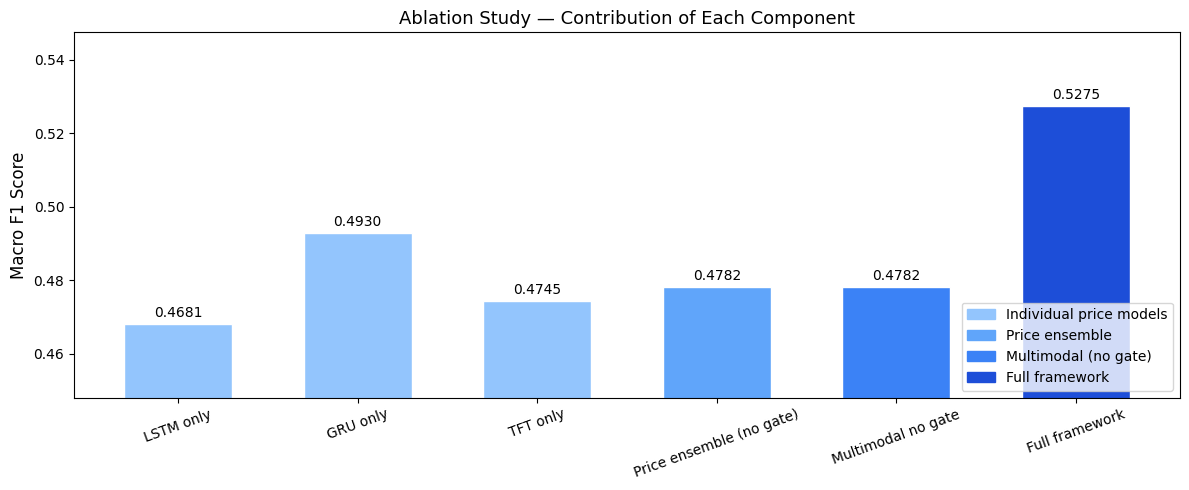

Ablation chart saved.


In [ ]:
### NB5 Cell 9 — Plot ablation bar chart ###
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
conditions = ablation_df['condition'].tolist()
f1_scores  = ablation_df['f1_macro'].tolist()
colors     = ['#93c5fd']*3 + ['#60a5fa'] + ['#3b82f6'] + ['#1d4ed8']

bars = ax.bar(conditions, f1_scores, color=colors, width=0.6, edgecolor='white')
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title('Ablation Study — Contribution of Each Component', fontsize=13)
ax.set_ylim(min(f1_scores) - 0.02, max(f1_scores) + 0.02)
ax.tick_params(axis='x', rotation=20)

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

legend_patches = [
    mpatches.Patch(color='#93c5fd', label='Individual price models'),
    mpatches.Patch(color='#60a5fa', label='Price ensemble'),
    mpatches.Patch(color='#3b82f6', label='Multimodal (no gate)'),
    mpatches.Patch(color='#1d4ed8', label='Full framework'),
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
(ROOT / 'outputs/figures').mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT / 'outputs/figures/ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation chart saved.")

In [ ]:
### NB5 Cell 10 — Final test-set evaluation ###
import json
final_metrics = compute_metrics(y_te_np, preds_full, 'Full framework')
final_metrics['gate_activation_rate'] = round(gates_full.mean(), 4)
final_metrics['mean_confidence']      = round(confs_full.mean(), 4)
final_metrics['n_test_samples']       = int(len(y_te_np))

print("\n" + "="*50)
print("FINAL TEST SET RESULTS")
print("="*50)
print(json.dumps(final_metrics, indent=2))

(ROOT / 'outputs/final_metrics.json').write_text(json.dumps(final_metrics, indent=2))
print("\nSaved to outputs/final_metrics.json")


FINAL TEST SET RESULTS
{
  "condition": "Full framework",
  "accuracy": 0.5284,
  "precision": 0.5658,
  "recall": 0.4581,
  "f1_macro": 0.5275,
  "mcc": 0.0657,
  "gate_activation_rate": 0.1997,
  "mean_confidence": 0.025,
  "n_test_samples": 13713
}

Saved to outputs/final_metrics.json


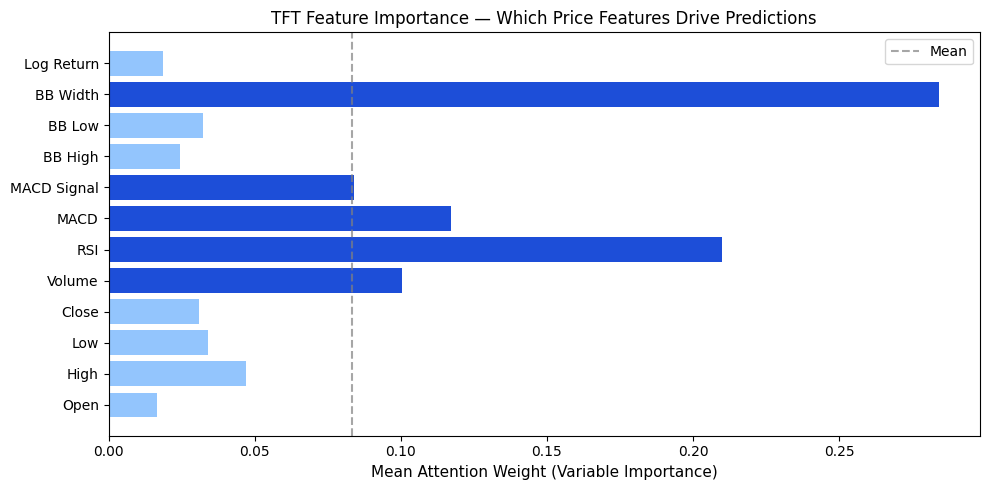

Feature importance chart saved.


In [ ]:
### NB5 Cell 11 — TFT feature importance plot ###
tft.eval()
with torch.no_grad():
    _ = tft(X_te[:256].to(device))

importance = tft.get_feature_importance()
feature_names = ['Open','High','Low','Close','Volume',
                 'RSI','MACD','MACD Signal',
                 'BB High','BB Low','BB Width','Log Return']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1d4ed8' if v > importance.mean() else '#93c5fd' for v in importance]
bars = ax.barh(feature_names, importance, color=colors)
ax.set_xlabel('Mean Attention Weight (Variable Importance)', fontsize=11)
ax.set_title('TFT Feature Importance — Which Price Features Drive Predictions', fontsize=12)
ax.axvline(importance.mean(), color='gray', linestyle='--', alpha=0.7, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures/tft_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")

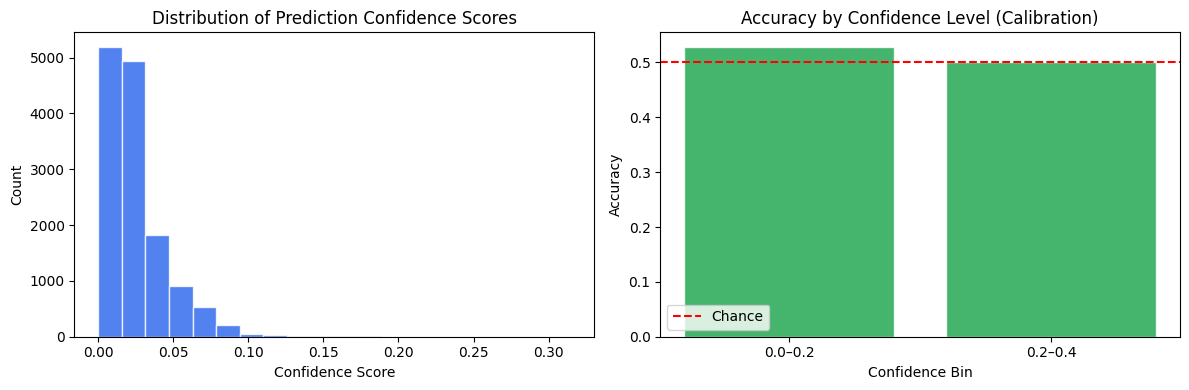

Confidence analysis saved.


In [ ]:
### NB5 Cell 12 — Confidence distribution plot ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(confs_full, bins=20, color='#2563EB', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Prediction Confidence Scores')

bins     = np.linspace(0, 1, 6)
bin_accs = []
bin_labs = []
for i in range(len(bins)-1):
    mask = (confs_full >= bins[i]) & (confs_full < bins[i+1])
    if mask.sum() > 0:
        bin_accs.append(accuracy_score(y_te_np[mask], preds_full[mask]))
        bin_labs.append(f"{bins[i]:.1f}–{bins[i+1]:.1f}")

axes[1].bar(bin_labs, bin_accs, color='#16A34A', alpha=0.8, edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', label='Chance')
axes[1].set_xlabel('Confidence Bin')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy by Confidence Level (Calibration)')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures/confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confidence analysis saved.")

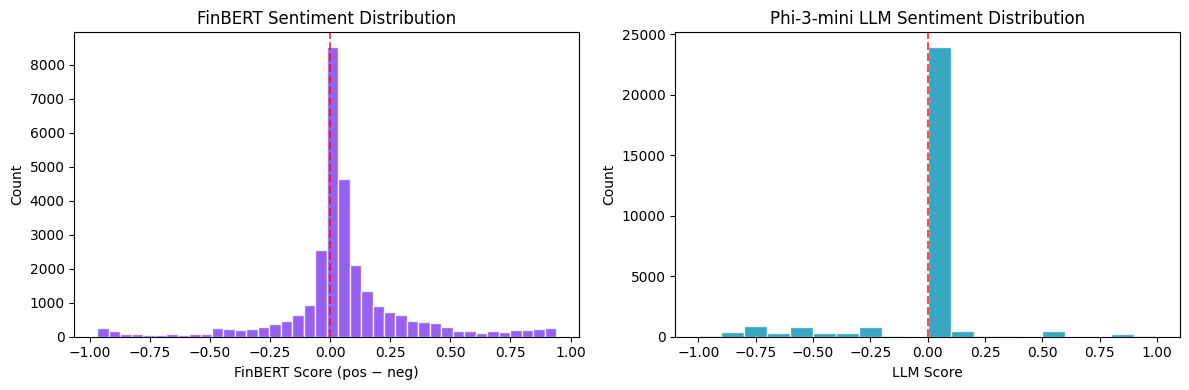

Sentiment distribution plots saved.

COMPLETE RESULTS SUMMARY

ABLATION STUDY (Test Set):
----------------------------------------------------------------------
Condition                         Acc   Prec    Rec     F1    MCC
----------------------------------------------------------------------
LSTM only                      0.4785 0.5094 0.3211 0.4681 -0.0260
GRU only                       0.4959 0.5216 0.5414 0.4930 -0.0137
TFT only                       0.4785 0.5081 0.3715 0.4745 -0.0313
Price ensemble (no gate)       0.4803 0.5099 0.3953 0.4782 -0.0299
Multimodal no gate             0.4803 0.5099 0.3953 0.4782 -0.0299
Full framework                 0.5284 0.5658 0.4581 0.5275 0.0657
----------------------------------------------------------------------

FINAL FRAMEWORK METRICS:
  accuracy: 0.5284
  precision: 0.5658
  recall: 0.4581
  f1_macro: 0.5275
  mcc: 0.0657
  gate_activation_rate: 0.1997
  mean_confidence: 0.025
  n_test_samples: 13713

All figures saved to outputs/figur

In [ ]:
### NB5 Cell 13 — Sentiment score distribution plot ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sent['s_finbert'], bins=40, color='#7C3AED', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('FinBERT Score (pos − neg)')
axes[0].set_ylabel('Count')
axes[0].set_title('FinBERT Sentiment Distribution')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)

axes[1].hist(sent['s_llm'], bins=20, color='#0891B2', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('LLM Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Phi-3-mini LLM Sentiment Distribution')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures/sentiment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sentiment distribution plots saved.")

### NB5 Cell 14 — Print complete summary table ###
print("\n" + "="*70)
print("COMPLETE RESULTS SUMMARY")
print("="*70)

print("\nABLATION STUDY (Test Set):")
print("-"*70)
print(f"{'Condition':<30} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'MCC':>6}")
print("-"*70)
for _, row in ablation_df.iterrows():
    print(f"{row['condition']:<30} {row['accuracy']:>6.4f} "
          f"{row['precision']:>6.4f} {row['recall']:>6.4f} "
          f"{row['f1_macro']:>6.4f} {row['mcc']:>6.4f}")
print("-"*70)

print(f"\nFINAL FRAMEWORK METRICS:")
for k, v in final_metrics.items():
    if k != 'condition':
        print(f"  {k}: {v}")

print("\nAll figures saved to outputs/figures/")
print("All metrics saved to outputs/")

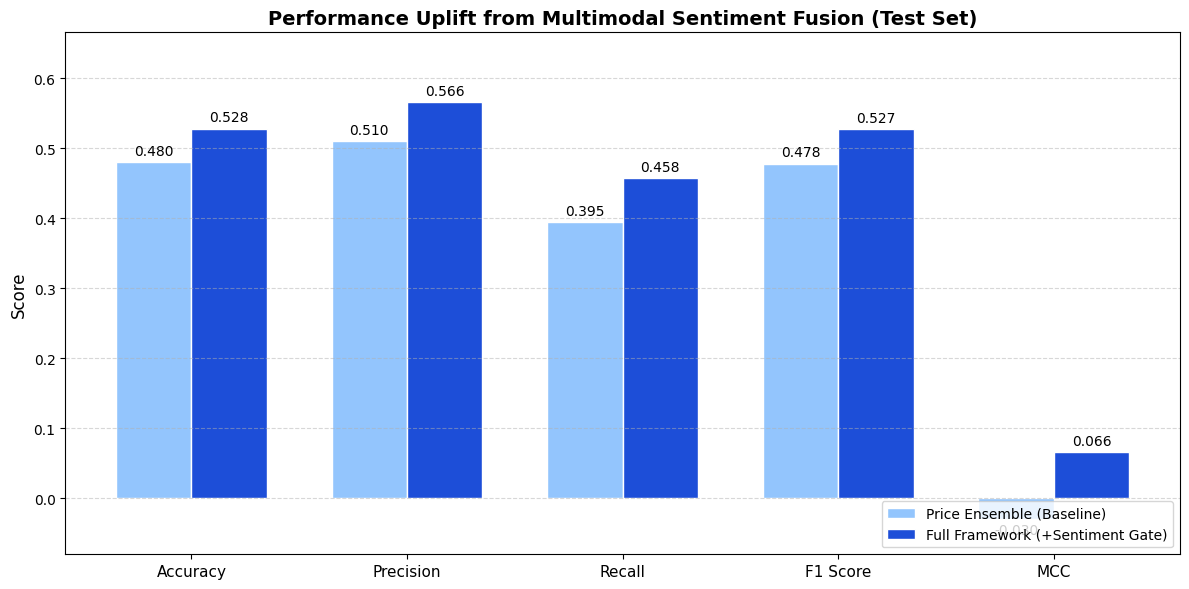

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_macro', 'mcc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MCC']

df_comparison = ablation_df[ablation_df['condition'].isin(
    ['Price ensemble (no gate)', 'Full framework'])].copy()

df_comparison['condition'] = pd.Categorical(df_comparison['condition'],
                             categories=['Price ensemble (no gate)', 'Full framework'])
df_comparison = df_comparison.sort_values('condition')

price_vals = df_comparison.iloc[0][metrics_to_plot].values.astype(float)
full_vals  = df_comparison.iloc[1][metrics_to_plot].values.astype(float)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, price_vals, width, label='Price Ensemble (Baseline)', color='#93c5fd', edgecolor='white')
rects2 = ax.bar(x + width/2, full_vals, width, label='Full Framework (+Sentiment Gate)', color='#1d4ed8', edgecolor='white')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Uplift from Multimodal Sentiment Fusion (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        va = 'bottom' if height >= 0 else 'top'
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -3),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=10)

autolabel(rects1)
autolabel(rects2)

min_y = min(np.concatenate([price_vals, full_vals]))
max_y = max(np.concatenate([price_vals, full_vals]))
ax.set_ylim(min_y - 0.05, max_y + 0.1)

fig.tight_layout()
(ROOT / 'outputs/figures').mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT / 'outputs/figures/final_uplift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()